In [ ]:
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. CONFIGURATION
# ==========================================
N_GRID = 64
N_NODES = N_GRID + 1
WIDTH = 64
MODES = 8        
BATCH_SIZE = 32
EPOCHS = 10001      
N_SAMPLES = 1000 
TRAIN_SAMPLES = 800
MAX_STEPS = 20
DT = 0.02
RHO_CP = 5.0
GRID = jnp.linspace(0, 1, N_NODES)

# ==========================================
# 2. PHYSICS & WEAK FORM RESIDUALS
# ==========================================
@jax.jit
def generate_smooth_fn(key):
    x = jnp.linspace(0, 1, N_NODES)
    k1, k2 = jax.random.split(key, 2)
    freqs = jax.random.uniform(k1, (3,), minval=1.0, maxval=3.0)
    amps = jax.random.uniform(k2, (3,), minval=0.1, maxval=0.3)
    return jnp.sum(amps[:, None] * jnp.sin(freqs[:, None] * jnp.pi * x), axis=0)

@jax.jit
def generate_complex_fn(key):
    x = jnp.linspace(0, 1, N_NODES)
    k1, k2, k3, k4 = jax.random.split(key, 4)
    freqs = jax.random.uniform(k1, (3,), minval=1.0, maxval=3.0)
    amps = jax.random.uniform(k2, (3,), minval=0.1, maxval=0.3)
    smooth = jnp.sum(amps[:, None] * jnp.sin(freqs[:, None] * jnp.pi * x), axis=0)
    edge_pos = jax.random.uniform(k3, (), minval=0.2, maxval=0.8)
    edge_height = jax.random.uniform(k4, (), minval=-0.3, maxval=0.3)
    sharp = jnp.where(x < edge_pos, edge_height, 0.0)
    return smooth + sharp

@jax.jit
def solve_transient_fem_step(T_n, alpha_x):
    dx = 1.0 / N_GRID
    K_mat = jnp.zeros((N_NODES, N_NODES))
    M_mat = jnp.zeros((N_NODES, N_NODES))
    k_nodal = alpha_x * (0.5 + T_n**2)
    for e in range(N_GRID):
        ix = jnp.array([e, e + 1])
        k_avg = 0.5 * (k_nodal[e] + k_nodal[e+1])
        ke = (k_avg / dx) * jnp.array([[1.0, -1.0], [-1.0, 1.0]])
        me = (RHO_CP * dx / 6.0) * jnp.array([[2.0, 1.0], [1.0, 2.0]])
        K_mat = K_mat.at[jnp.ix_(ix, ix)].add(ke)
        M_mat = M_mat.at[jnp.ix_(ix, ix)].add(me)
    LHS = M_mat + DT * K_mat
    RHS = M_mat @ T_n
    free = jnp.arange(1, N_NODES - 1)
    RHS_free = RHS[free] - LHS[free, 0] * 1.0 - LHS[free, -1] * 0.0
    T_next_free = jnp.linalg.solve(LHS[jnp.ix_(free, free)], RHS_free)
    return jnp.zeros(N_NODES).at[0].set(1.0).at[-1].set(0.0).at[free].set(T_next_free)

@jax.jit
def compute_weak_residual(T_next, T_curr, alpha_x):
    """
    Evaluates the algebraic weak form residual (LHS * T_next - RHS)
    on internal nodes based on the physical state.
    """
    dx = 1.0 / N_GRID
    K_mat = jnp.zeros((N_NODES, N_NODES))
    M_mat = jnp.zeros((N_NODES, N_NODES))
    
    k_nodal = alpha_x * (0.5 + T_curr**2)
    for e in range(N_GRID):
        ix = jnp.array([e, e + 1])
        k_avg = 0.5 * (k_nodal[e] + k_nodal[e+1])
        ke = (k_avg / dx) * jnp.array([[1.0, -1.0], [-1.0, 1.0]])
        me = (RHO_CP * dx / 6.0) * jnp.array([[2.0, 1.0], [1.0, 2.0]])
        K_mat = K_mat.at[jnp.ix_(ix, ix)].add(ke)
        M_mat = M_mat.at[jnp.ix_(ix, ix)].add(me)
        
    LHS = M_mat + DT * K_mat
    RHS = M_mat @ T_curr
    
    residual =  (LHS @ T_next - RHS)
    free = jnp.arange(1, N_NODES - 1)
    return residual[free]

@jax.jit
def generate_trajectory(key_k, key_t):
    alpha = jax.nn.sigmoid(generate_smooth_fn(key_k)) * 0.4 + 0.1
    T0_signal = generate_complex_fn(key_t)
    ramp = jnp.linspace(1.0, 0.0, N_NODES)
    mask = jnp.sin(jnp.pi * jnp.linspace(0, 1, N_NODES))
    T0 = ramp + (T0_signal * mask)
    def step_fn(T_curr, _):
        T_next = solve_transient_fem_step(T_curr, alpha)
        return T_next, (T_curr, T_next)
    _, (inputs, targets) = jax.lax.scan(step_fn, T0, None, length=MAX_STEPS-1)
    return inputs, targets, alpha, T0

def fem_rollout(T_init, alpha_prof, steps):
    def step(T_curr, _): 
        val = solve_transient_fem_step(T_curr, alpha_prof)
        return val, val
    return jnp.vstack([T_init, jax.lax.scan(step, T_init, None, length=steps)[1]])

# ==========================================
# 3. FOURIER NEURAL OPERATOR (MODEL)
# ==========================================
def spectral_layer(x, w_spec, w_skip):
    n = x.shape[0]
    x_ft = jnp.fft.rfft(x, axis=0)
    out_ft = jnp.zeros_like(x_ft, dtype=jnp.complex64).at[:MODES].set(
        jnp.einsum('mi, mij -> mj', x_ft[:MODES], w_spec))
    return jax.nn.gelu(jnp.fft.irfft(out_ft, n=n, axis=0) + jnp.dot(x, w_skip))

def fno_model(params, x_norm, T_curr):
    x = jax.nn.gelu(jnp.dot(x_norm, params[0]) + params[1])
    for i in range(2, 10, 2):
        x = spectral_layer(x, params[i], params[i+1])
    x = jax.nn.gelu(jnp.dot(x, params[10]) + params[11])
    res = (jnp.dot(x, params[12]) + params[13]).squeeze()
    mask = jnp.sin(jnp.pi * jnp.linspace(0, 1, N_NODES))
    return T_curr + (res * mask)

def init_params(key):
    keys = jax.random.split(key, 12)
    def norm_init(k, s): return jax.random.normal(k, s) * jnp.sqrt(1.0 / s[-1])
    p = [norm_init(keys[0], (3, WIDTH)), jnp.zeros(WIDTH)]
    for i in range(4):
        p.append(jax.random.normal(keys[i+1], (MODES, WIDTH, WIDTH), dtype=jnp.complex64) * 0.02)
        p.append(norm_init(keys[i+5], (WIDTH, WIDTH)))
    p.extend([norm_init(keys[10], (WIDTH, WIDTH)), jnp.zeros(WIDTH), 
              norm_init(keys[11], (WIDTH, 1)), jnp.zeros(1)])
    return p

# ==========================================
# 4. DATA PIPELINE PREPARATION
# ==========================================
print("Generating Underlying Synthetic Space...")
keys_k = jax.random.split(jax.random.PRNGKey(42), N_SAMPLES)
keys_t = jax.random.split(jax.random.PRNGKey(7), N_SAMPLES)
all_X_T, all_Y_T, all_Alpha, all_T0 = jax.vmap(generate_trajectory)(keys_k, keys_t)

VAL_SAMPLES = 100  
grid_expanded = jnp.tile(GRID, (N_SAMPLES, MAX_STEPS-1, 1))
X_raw = jnp.stack([all_X_T, jnp.tile(all_Alpha[:, None, :], (1, MAX_STEPS-1, 1)), grid_expanded], axis=-1)
Y_raw = all_Y_T[..., None]

# Train Set Raw Inputs (No Target Y Used In Physics-Loss Loop)
X_train_flat = X_raw[:TRAIN_SAMPLES].reshape(-1, N_NODES, 3)

# Validation Sets (Kept to crosscheck real accuracy drops during optimization)
X_val_flat = X_raw[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES].reshape(-1, N_NODES, 3)
Y_val_flat = Y_raw[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES].reshape(-1, N_NODES, 1)

# Normalization parameters based on training features
x_mean, x_std = X_train_flat.mean(axis=(0, 1)), X_train_flat.std(axis=(0, 1)) + 1e-7
X_train_norm = (X_train_flat - x_mean) / x_std
X_val_norm = (X_val_flat - x_mean) / x_std

# ==========================================
# 5. PHYSICS-INFORMED LOSS & OPTIMIZATION
# ==========================================
params = init_params(jax.random.PRNGKey(123))
lr_schedule = optax.cosine_decay_schedule(init_value=1e-3, decay_steps=EPOCHS, alpha=1e-2)
optimizer = optax.adamw(learning_rate=lr_schedule, weight_decay=1e-4)
opt_state = optimizer.init(params)

@jax.jit
def train_step(p, opt_s, b_X_norm, b_X_raw):
    T_curr_batch = b_X_raw[:, :, 0]
    alpha_batch = b_X_raw[:, :, 1]
    
    def loss_fn(p):
        # 1. Predict state transition using FNO
        T_next_pred = jax.vmap(fno_model, (None, 0, 0))(p, b_X_norm, T_curr_batch)
        # 2. Evaluate physical model discrepancies (Weak Residual) via vmap
        residuals = jax.vmap(compute_weak_residual, (0, 0, 0))(T_next_pred, T_curr_batch, alpha_batch)
        return jnp.mean(residuals**2)
        
    l, g = jax.value_and_grad(loss_fn)(p)
    u, opt_s = optimizer.update(g, opt_s, p)
    return optax.apply_updates(p, u), opt_s, l

@jax.jit
def evaluate_validation_data_loss(p, b_X_norm, b_X_raw, b_Y):
    T_curr_batch = b_X_raw[:, :, 0]
    preds = jax.vmap(fno_model, (None, 0, 0))(p, b_X_norm, T_curr_batch)
    return jnp.mean((preds - b_Y.squeeze())**2)

loss_history, val_history, epochs_recorded = [], [], []

print(f"Training for {EPOCHS} epochs using self-supervised weak-form residuals...")
for i in range(EPOCHS):
    idx = jax.random.randint(jax.random.PRNGKey(i), (BATCH_SIZE,), 0, X_train_flat.shape[0])
    
    # Run optimization step (Notice how Y targets are completely missing)
    params, opt_state, loss = train_step(params, opt_state, X_train_norm[idx], X_train_flat[idx])
    
    if i % 100 == 0:
        val_loss = evaluate_validation_data_loss(params, X_val_norm, X_val_flat, Y_val_flat)
        loss_history.append(float(loss))
        val_history.append(float(val_loss))
        epochs_recorded.append(i)
        
    if i % 1000 == 0: 
        print(f"Epoch {i:4d} | Physics Residual MSE: {loss:.6e} | Val Data Mismatch MSE: {val_loss:.6e}")

# ==========================================
# 6. TIME ROLLOUT EVALUATION
# ==========================================
test_idx = TRAIN_SAMPLES + VAL_SAMPLES + 5
T0_test, alpha_test = all_T0[test_idx], all_Alpha[test_idx]

def rollout_fno(p, T_init, alpha_prof, steps):
    def step(T_curr, _):
        x_norm = (jnp.stack([T_curr, alpha_prof, GRID], axis=-1) - x_mean) / x_std
        T_next = fno_model(p, x_norm, T_curr)
        return T_next, T_next
    return jax.lax.scan(step, T_init, None, length=steps)[1]

true_traj = fem_rollout(T0_test, alpha_test, MAX_STEPS-1)
fno_traj = jnp.vstack([T0_test, rollout_fno(params, T0_test, alpha_test, MAX_STEPS-1)])
abs_error = jnp.abs(true_traj - fno_traj)



Generating Underlying Synthetic Space...
Training for 10001 epochs using self-supervised weak-form residuals...
Epoch    0 | Physics Residual MSE: 3.034493e-05 | Val Data Mismatch MSE: 2.739213e-04
Epoch 1000 | Physics Residual MSE: 1.579944e-07 | Val Data Mismatch MSE: 1.163371e-05
Epoch 2000 | Physics Residual MSE: 1.298201e-07 | Val Data Mismatch MSE: 7.480380e-06
Epoch 3000 | Physics Residual MSE: 9.107662e-08 | Val Data Mismatch MSE: 6.413925e-06
Epoch 4000 | Physics Residual MSE: 4.881672e-07 | Val Data Mismatch MSE: 4.596071e-06
Epoch 5000 | Physics Residual MSE: 2.030089e-07 | Val Data Mismatch MSE: 3.712327e-06
Epoch 6000 | Physics Residual MSE: 1.666067e-07 | Val Data Mismatch MSE: 3.631050e-06
Epoch 7000 | Physics Residual MSE: 4.763439e-08 | Val Data Mismatch MSE: 3.442070e-06
Epoch 8000 | Physics Residual MSE: 2.276095e-07 | Val Data Mismatch MSE: 3.282134e-06
Epoch 9000 | Physics Residual MSE: 2.146048e-08 | Val Data Mismatch MSE: 3.123913e-06
Epoch 10000 | Physics Residu

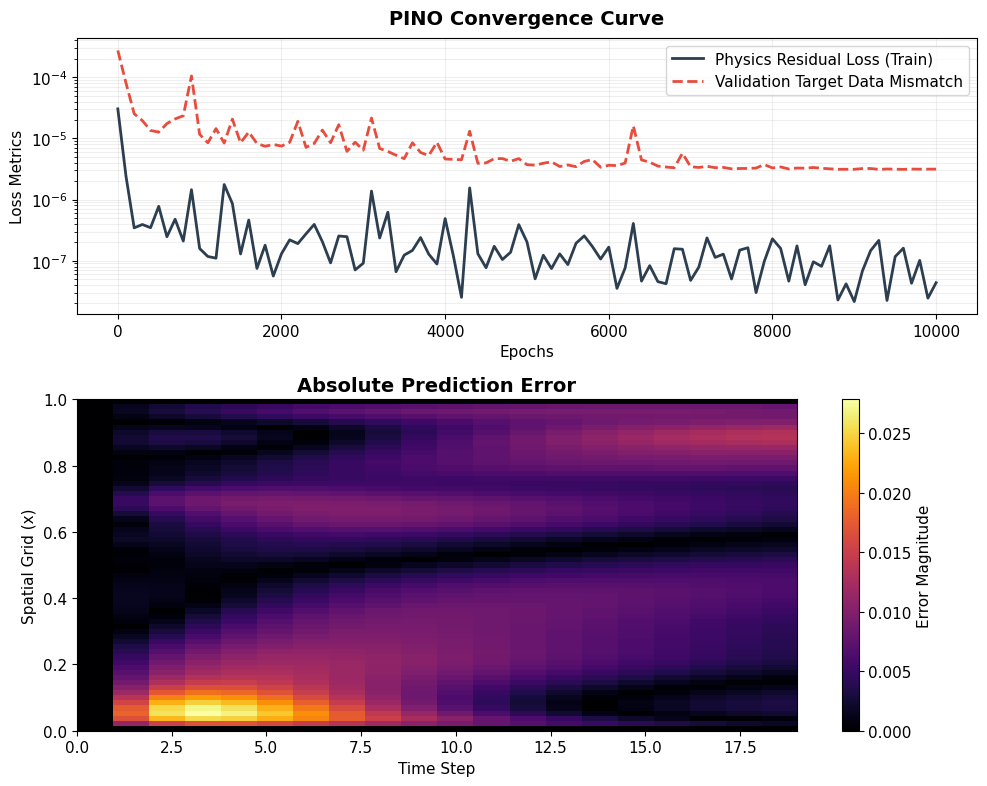

In [ ]:
# ==========================================
# 7. POST-PROCESSING VISUALIZATION
# ==========================================
plt.rcParams.update({'font.size': 11})
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1.2])

# Plot 0: Convergence Curve
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(epochs_recorded, loss_history, color='#2c3e50', lw=2, label='Physics Residual Loss (Train)')
ax0.plot(epochs_recorded, val_history, color='#e74c3c', lw=2, ls='--', label='Validation Target Data Mismatch')
ax0.set_yscale('log')
ax0.set_title("PINO Convergence Curve", fontweight='bold', fontsize=14, pad=10)
ax0.set_xlabel("Epochs")
ax0.set_ylabel("Loss Metrics")
ax0.grid(True, which="both", ls="-", alpha=0.2)
ax0.legend(loc='upper right')

# Plot 1: Absolute Error
ax1 = fig.add_subplot(gs[1, 0])
im1 = ax1.imshow(abs_error.T, aspect='auto', origin='lower', cmap='inferno', extent=[0, MAX_STEPS-1, 0, 1])
ax1.set_title("Absolute Prediction Error", fontweight='bold', fontsize=14)
ax1.set_xlabel("Time Step")
ax1.set_ylabel("Spatial Grid (x)")
fig.colorbar(im1, ax=ax1, label="Error Magnitude")

plt.tight_layout()
plt.show()

Computing full rollout errors for all samples...


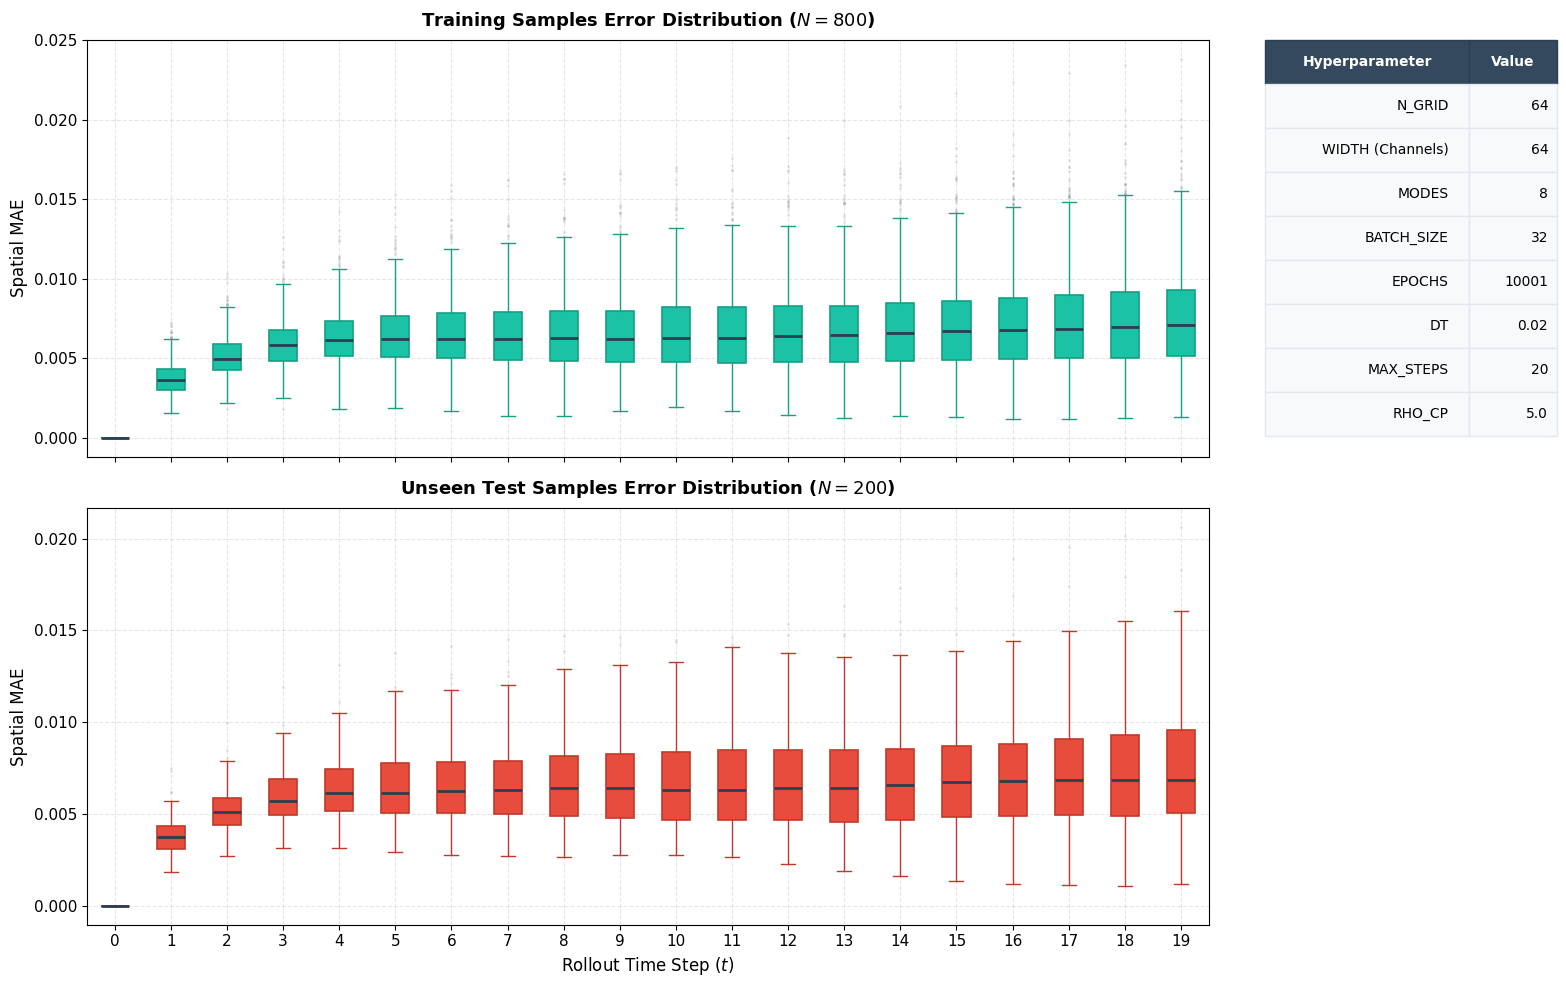

In [3]:
# =====================================================================
# 1. COMPUTE BATCHED ROLLOUT ERRORS (TRAIN vs TEST)
# =====================================================================
print("Computing full rollout errors for all samples...")

@jax.jit(static_argnums=(3,))
def batch_rollout_fno(p, T0_batch, alpha_batch, steps):
    """Performs autoregressive rollout for an entire batch of trajectories."""
    def step(T_curr, _):
        grid_b = jnp.tile(GRID, (T0_batch.shape[0], 1))
        x_raw = jnp.stack([T_curr, alpha_batch, grid_b], axis=-1)
        x_norm = (x_raw - x_mean) / x_std
        T_next = jax.vmap(fno_model, (None, 0, 0))(p, x_norm, T_curr)
        return T_next, T_next

    _, traj = jax.lax.scan(step, T0_batch, None, length=steps)
    traj = jnp.transpose(traj, (1, 0, 2))
    return jnp.concatenate([T0_batch[:, None, :], traj], axis=1)

# Reconstruct ground truth and split datasets
true_traj_all = jnp.concatenate([all_T0[:, None, :], all_Y_T], axis=1)
true_train = true_traj_all[:TRAIN_SAMPLES]
true_test = true_traj_all[TRAIN_SAMPLES:]

# Generate FNO predictions
pred_train = batch_rollout_fno(params, all_T0[:TRAIN_SAMPLES], all_Alpha[:TRAIN_SAMPLES], MAX_STEPS-1)
pred_test  = batch_rollout_fno(params, all_T0[TRAIN_SAMPLES:], all_Alpha[TRAIN_SAMPLES:], MAX_STEPS-1)

# Calculate Mean Absolute Error across spatial nodes per time step
spatial_mae_train = jnp.mean(jnp.abs(true_train - pred_train), axis=2)
spatial_mae_test  = jnp.mean(jnp.abs(true_test - pred_test), axis=2)


# =====================================================================
# 2. BOX PLOT VISUALIZATION WITH HYPERPARAMETER TABLE
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np

def plot_error_boxplots(mae_train, mae_test):
    mae_train_np = np.array(mae_train)
    mae_test_np = np.array(mae_test)
    
    n_steps = mae_train_np.shape[1]
    steps = np.arange(n_steps)
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
    plt.rcParams.update({'font.size': 11})
    
    flier_props = dict(marker='.', markersize=4, markerfacecolor='#7f8c8d', 
                       markeredgecolor='none', alpha=0.2)
    median_props = dict(color='#2c3e50', linewidth=2)

    # --- Panel 1: Training Set Distribution ---
    box_train = dict(facecolor='#1bc2a6', color='#16a085', linewidth=1.2)
    axes[0].boxplot(
        mae_train_np, positions=steps, patch_artist=True,
        boxprops=box_train, whiskerprops=dict(color='#16a085'),
        capprops=dict(color='#16a085'), medianprops=median_props, flierprops=flier_props
    )
    axes[0].set_title(f"Training Samples Error Distribution ($N={TRAIN_SAMPLES}$)", fontweight='bold', fontsize=13, pad=10)
    axes[0].set_ylabel("Spatial MAE", fontsize=12)
    axes[0].grid(True, linestyle='--', alpha=0.3)
    
    # --- Panel 2: Unseen Test Set Distribution ---
    box_test = dict(facecolor='#e74c3c', color='#c0392b', linewidth=1.2)
    axes[1].boxplot(
        mae_test_np, positions=steps, patch_artist=True,
        boxprops=box_test, whiskerprops=dict(color='#c0392b'),
        capprops=dict(color='#c0392b'), medianprops=median_props, flierprops=flier_props
    )
    axes[1].set_title(f"Unseen Test Samples Error Distribution ($N={N_SAMPLES - TRAIN_SAMPLES}$)", fontweight='bold', fontsize=13, pad=10)
    axes[1].set_xlabel("Rollout Time Step ($t$)", fontsize=12)
    axes[1].set_ylabel("Spatial MAE", fontsize=12)
    axes[1].grid(True, linestyle='--', alpha=0.3)
    
    plt.xticks(steps, labels=[str(s) for s in steps])
    
    # --- 3. HYPERPARAMETER TABLE (FIXED CLIPPING) ---
    hyperparams = [
        ["N_GRID", str(N_GRID)],
        ["WIDTH (Channels)", str(WIDTH)],
        ["MODES", str(MODES)],
        ["BATCH_SIZE", str(BATCH_SIZE)],
        ["EPOCHS", str(EPOCHS)],
        ["DT", str(DT)],
        ["MAX_STEPS", str(MAX_STEPS)],
        ["RHO_CP", str(RHO_CP)]
    ]
    
    # Adjusted rect to give 23% space on the right for the wider table
    plt.tight_layout(rect=[0, 0, 0.77, 1])
    
    # Added colWidths [70%, 30%] allocation and increased total bbox width to 0.26
    param_table = axes[0].table(
        cellText=hyperparams,
        colLabels=['Hyperparameter', 'Value'],
        loc='upper right',
        colWidths=[0.70, 0.30],
        bbox=[1.05, 0.05, 0.26, 0.95]
    )
    
    param_table.auto_set_font_size(False)
    param_table.set_fontsize(10)
    
    # Clean formatting for headers and data rows
    for (row, col), cell in param_table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#34495e')
            cell.set_edgecolor('#2c3e50')
        else:
            cell.set_facecolor('#f8f9fa')
            cell.set_edgecolor('#e2e8f0')

    plt.show()

# Run the updated plotting routine
plot_error_boxplots(spatial_mae_train, spatial_mae_test)

Randomly selected test indices: [921 835 930]


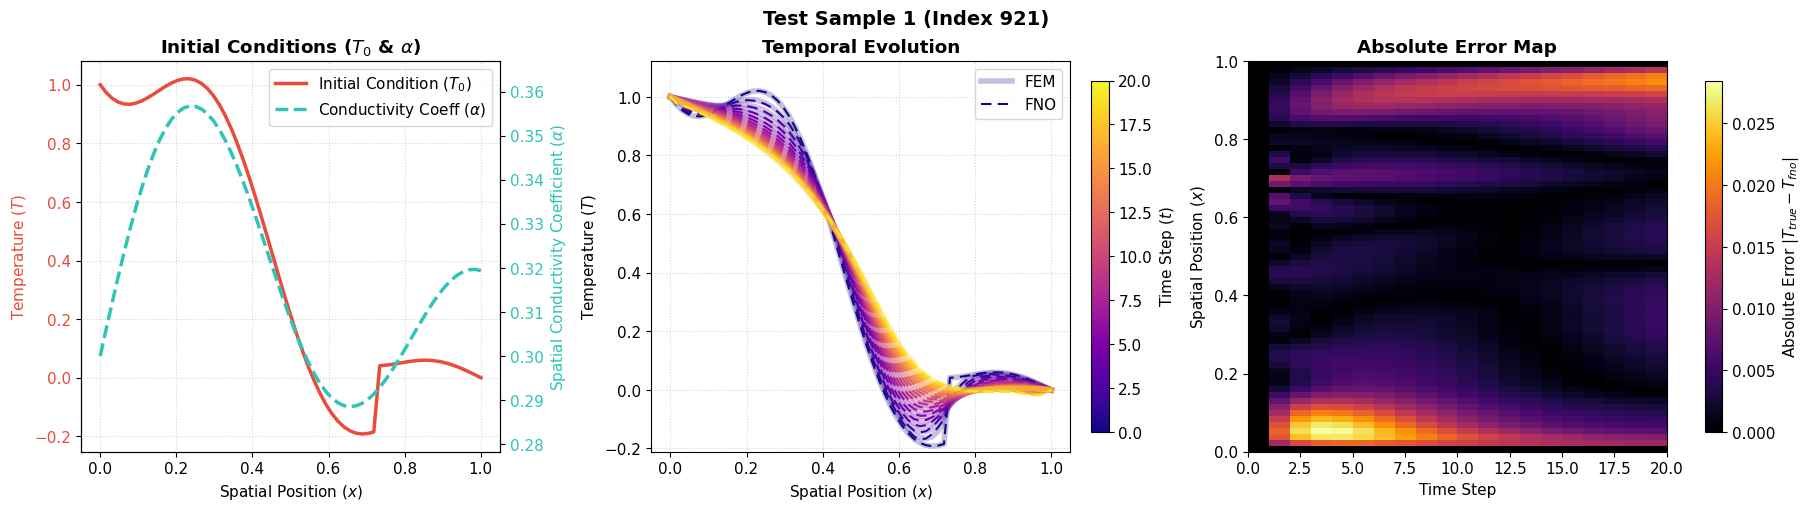

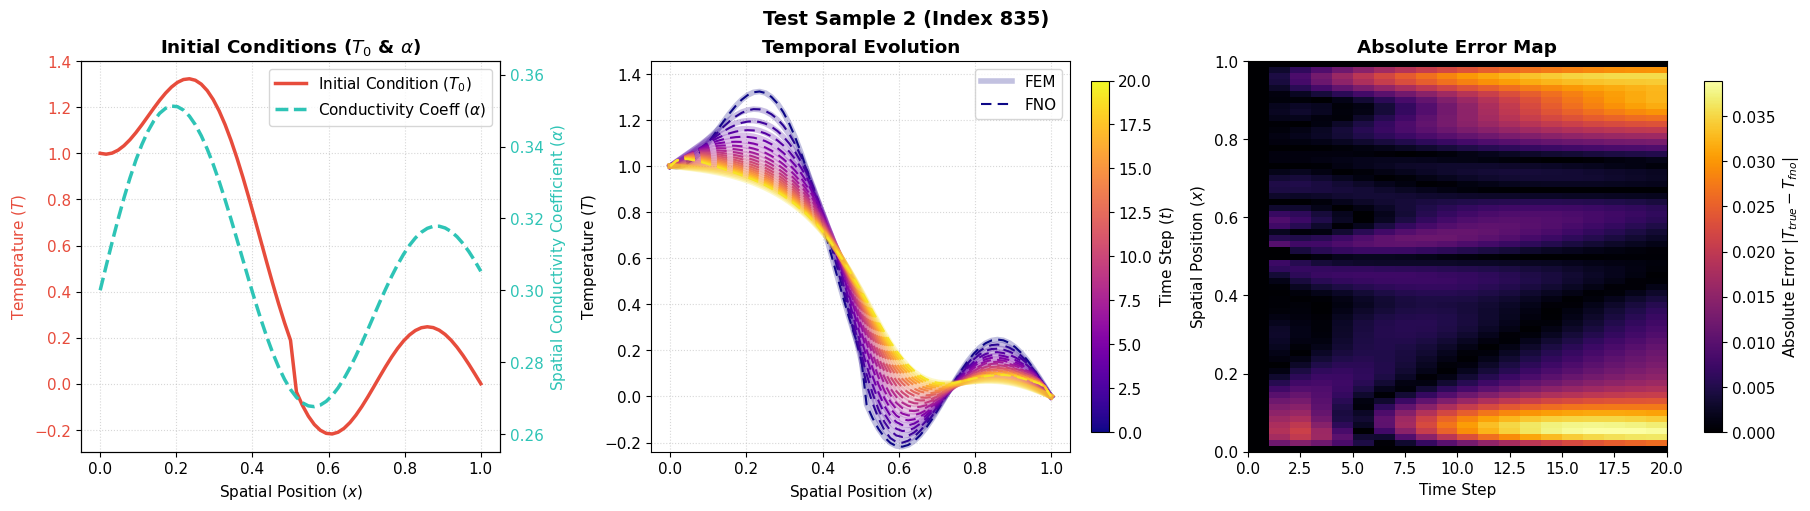

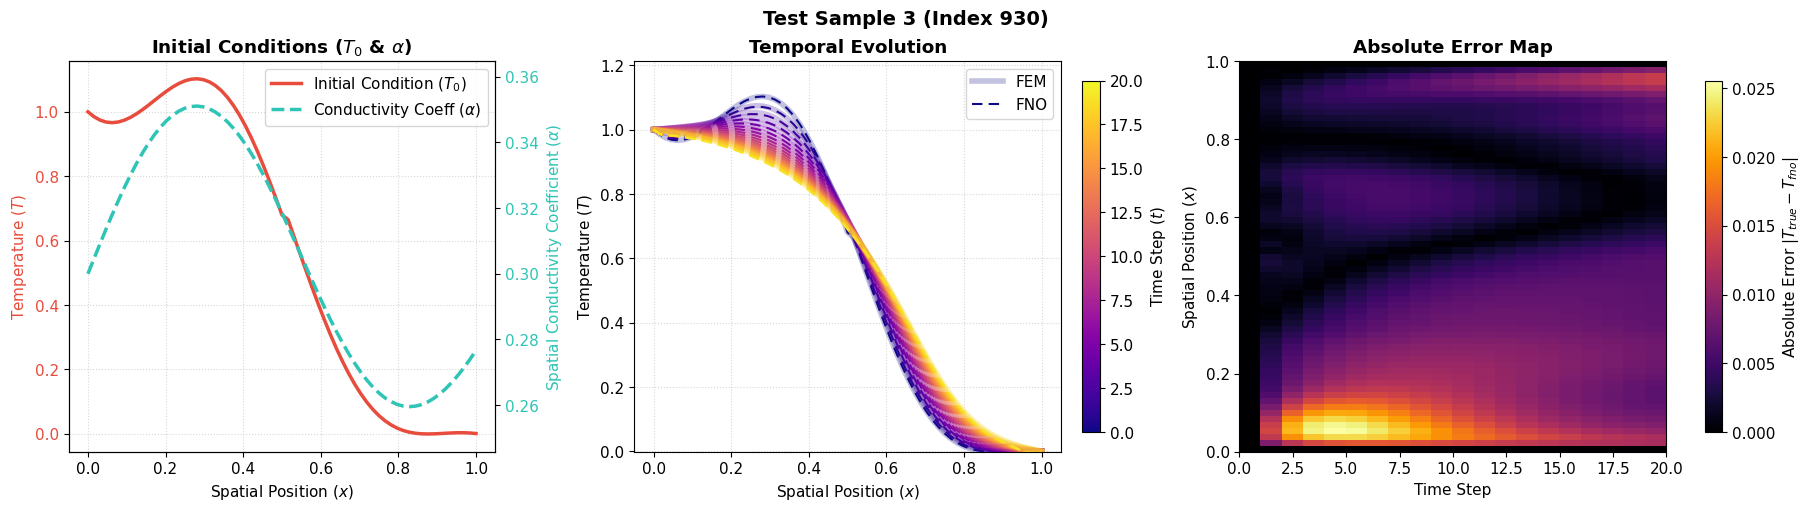

In [7]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- 1. RANDOM TEST SELECTION ---
NUM_TEST_SAMPLES = 3  # How many random samples to visualize
test_key = jax.random.PRNGKey(42)  # Change seed for different random samples

# Define the pool (only indices the model hasn't seen during training)
test_pool = jnp.arange(TRAIN_SAMPLES, N_SAMPLES)

# Choose random indices from the test pool
test_indices = jax.random.choice(test_key, test_pool, shape=(NUM_TEST_SAMPLES,), replace=False)

print(f"Randomly selected test indices: {test_indices}")

cmap = plt.get_cmap('plasma')

# --- 2. EVALUATION & VISUALIZATION LOOP ---
for i, test_idx in enumerate(test_indices):
    # Retrieve data for this random index
    T0_test, alpha_test = all_T0[test_idx], all_Alpha[test_idx]
    
    # Generate trajectories (Using local scope functions)
    true_traj = fem_rollout(T0_test, alpha_test, MAX_STEPS-1)
    fno_pred = rollout_fno(params, T0_test, alpha_test, MAX_STEPS-1)
    fno_traj = jnp.vstack([T0_test, fno_pred])
    error_traj = jnp.abs(true_traj - fno_traj)
    
    # Create Figure: 1 Row, 3 Columns using constrained layout to prevent overlap warnings
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), layout="constrained")
    
    # --- COL 1: INITIAL TEMPERATURE & MATERIAL PROFILE (TWIN Y-AXIS) ---
    # Primary Axis: Temperature Profile
    line1 = ax1.plot(GRID, T0_test, color='#e74c3c', lw=2.5, label="Initial Condition ($T_0$)")
    ax1.set_xlabel("Spatial Position ($x$)")
    ax1.set_ylabel("Temperature ($T$)", color='#e74c3c')
    ax1.tick_params(axis='y', labelcolor='#e74c3c')
    ax1.grid(True, linestyle=':', alpha=0.5)
    
    # Secondary Axis: Spatial Conductivity Coefficient Profile
    ax1_twin = ax1.twinx()
    line2 = ax1_twin.plot(GRID, alpha_test, color='#2ec4b6', lw=2.5, ls='--', label="Conductivity Coeff ($\\alpha$)")
    ax1_twin.set_ylabel("Spatial Conductivity Coefficient ($\\alpha$)", color='#2ec4b6')
    ax1_twin.tick_params(axis='y', labelcolor='#2ec4b6')
    
    # Scale secondary axis limits cleanly to fit the dynamic alpha range
    alpha_min, alpha_max = jnp.min(alpha_test), jnp.max(alpha_test)
    alpha_range = abs(alpha_max - alpha_min) if alpha_max != alpha_min else float(alpha_max) * 0.1
    ax1_twin.set_ylim(float(alpha_min) - alpha_range * 0.15, float(alpha_max) + alpha_range * 0.15)
    
    # Combined Legend for both traces
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="upper right")
    
    ax1.set_title("Initial Conditions ($T_0$ & $\\alpha$)", fontweight='bold')
    
    # --- COL 2: TEMPERATURE EVOLUTION (LINE PLOTS) ---
    plot_steps = range(0, MAX_STEPS, 1)  # Plotting every step
    for t in plot_steps:
        color = cmap(t / MAX_STEPS)
        ax2.plot(GRID, true_traj[t], color=color, alpha=0.25, lw=4, label="FEM" if t==0 else "")
        ax2.plot(GRID, fno_traj[t], color=color, ls=(0, (5, 3)), lw=1.5, label="FNO" if t==0 else "")
        
    ax2.set_title("Temporal Evolution", fontweight='bold')
    ax2.set_xlabel("Spatial Position ($x$)")
    ax2.set_ylabel("Temperature ($T$)")
    ax2.grid(True, linestyle=':', alpha=0.5)
    ax2.legend(loc='upper right')
    
    # Dynamic Y-Limit for Temperature
    y_min, y_max = jnp.min(true_traj), jnp.max(true_traj)
    ax2.set_ylim(y_min - abs(y_min)*0.1, y_max + abs(y_max)*0.1)

    # Dedicated Colorbar for Evolution lines
    sm2 = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=MAX_STEPS))
    cbar2 = fig.colorbar(sm2, ax=ax2, aspect=20, shrink=0.9)
    cbar2.set_label('Time Step ($t$)')

    # --- COL 3: ERROR HEATMAP ---
    im3 = ax3.imshow(error_traj.T, extent=[0, MAX_STEPS, 0, 1], origin='lower', aspect='auto', cmap='inferno')
    ax3.set_title("Absolute Error Map", fontweight='bold')
    ax3.set_xlabel("Time Step")
    ax3.set_ylabel("Spatial Position ($x$)")
    
    # Dedicated Colorbar for the Heatmap
    cbar3 = fig.colorbar(im3, ax=ax3, aspect=20, shrink=0.9)
    cbar3.set_label('Absolute Error $|T_{true} - T_{fno}|$')

    fig.suptitle(f"Test Sample {i+1} (Index {test_idx})", fontsize=14, fontweight='bold')
    plt.show()

Analyzing Scenario: Top-Hat Pulse...


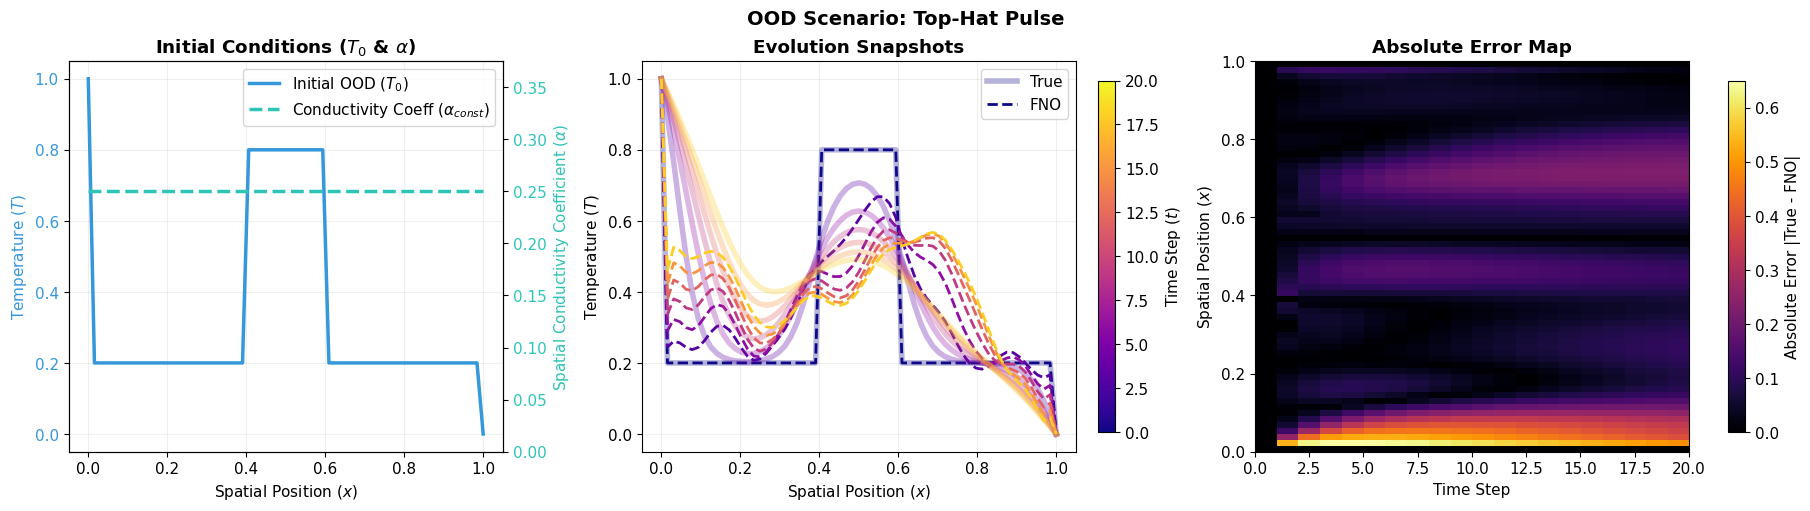

Analyzing Scenario: Sawtooth...


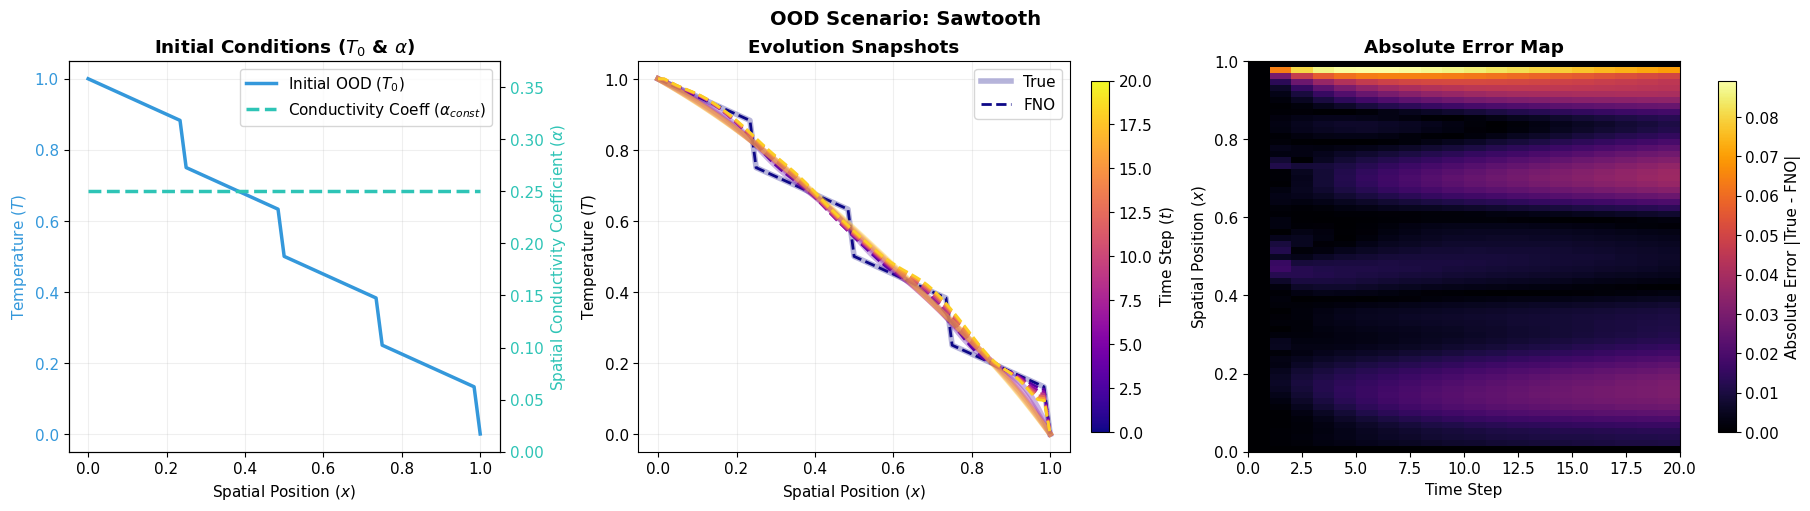

Analyzing Scenario: High-Freq Sine...


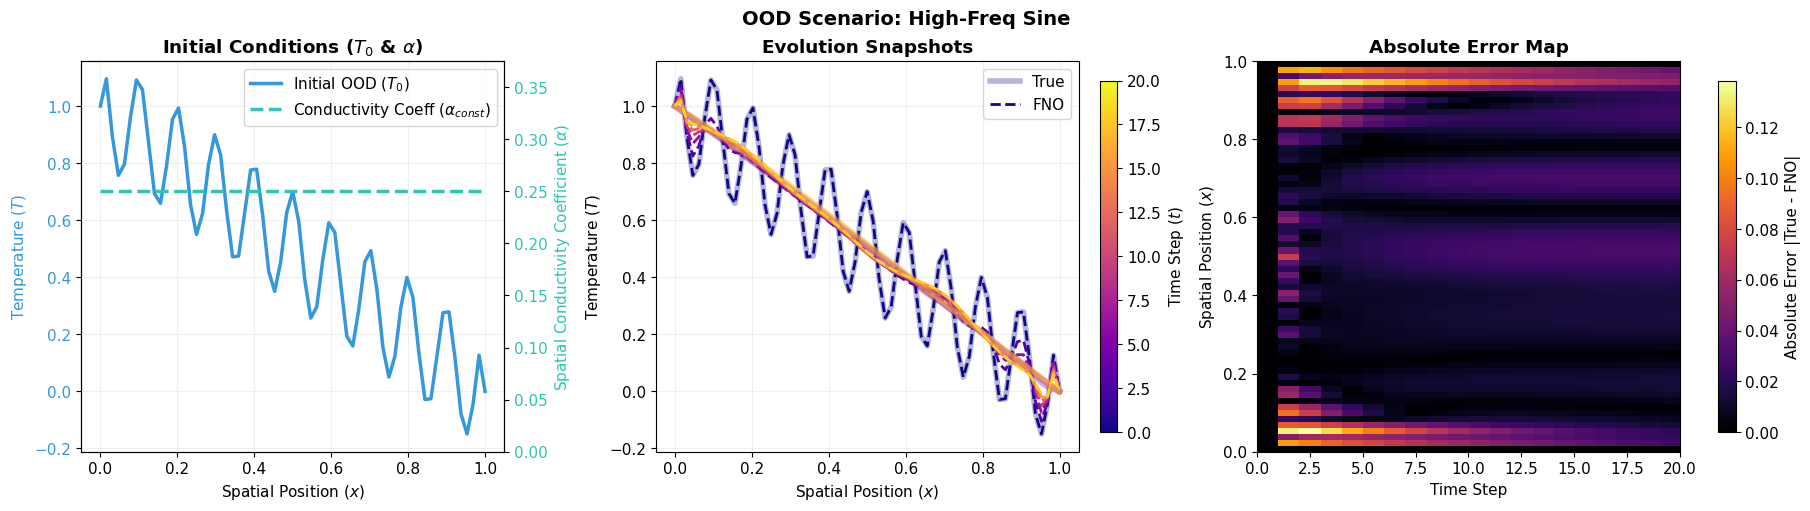

Analyzing Scenario: Double Staircase...


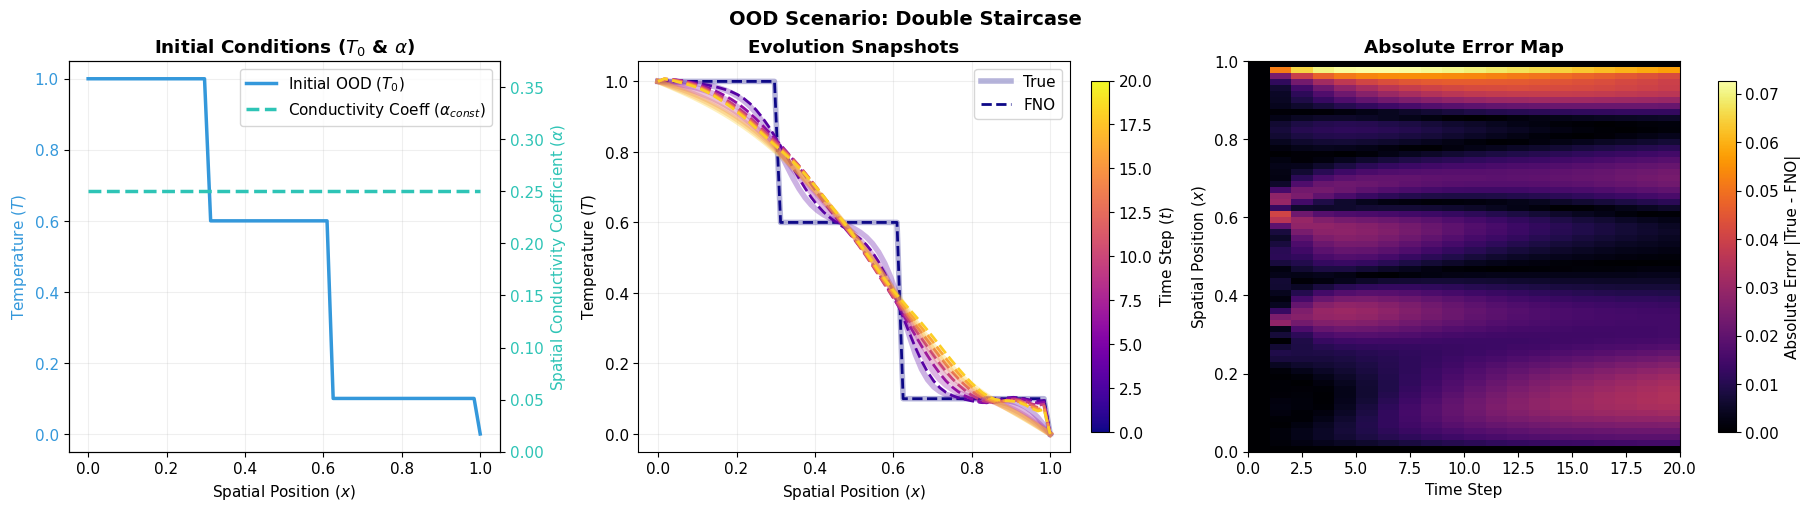

Analyzing Scenario: Exponential Spike...


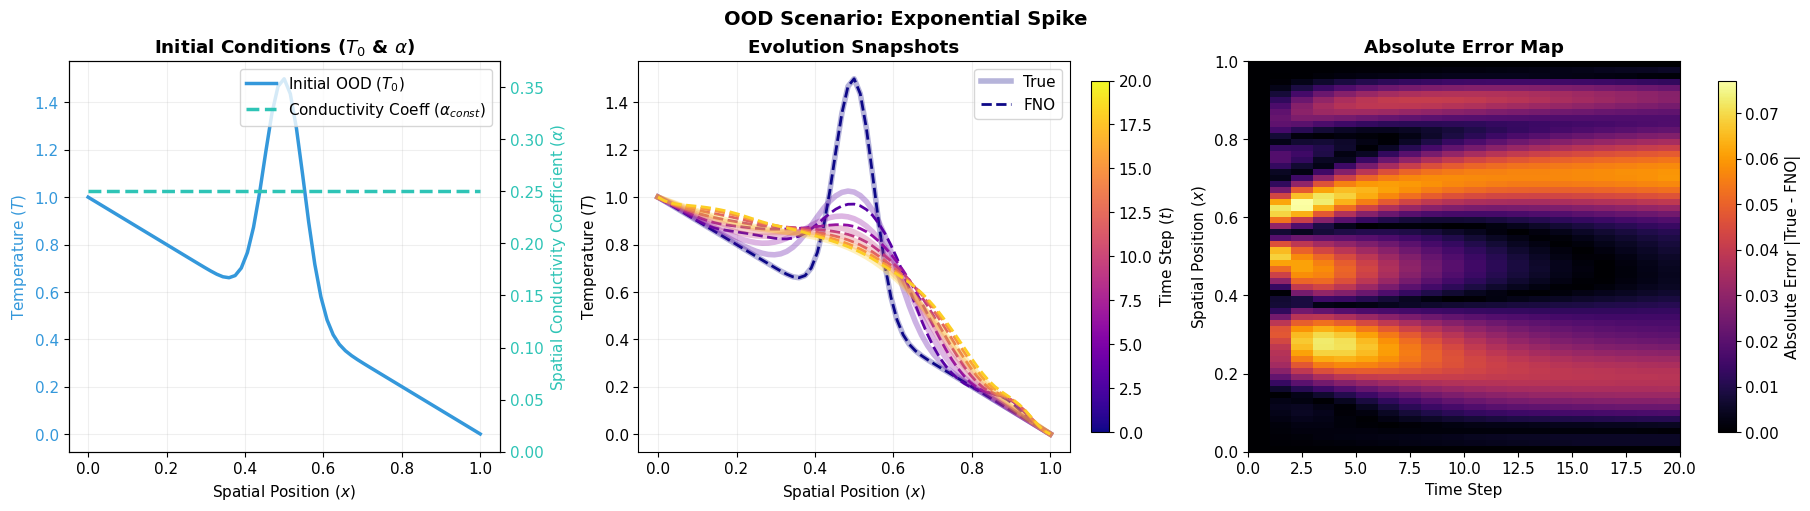

In [8]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 1. Define OOD Scenarios
ood_scenarios = {
    "Top-Hat Pulse": jnp.where((GRID > 0.4) & (GRID < 0.6), 0.8, 0.2),
    "Sawtooth": (1.0 - GRID + 0.5 * (GRID % 0.25)),
    "High-Freq Sine": (jnp.cos(20 * jnp.pi * GRID) * 0.2 + (1.0 - GRID)),
    "Double Staircase": jnp.zeros(N_NODES).at[:20].set(1.0).at[20:40].set(0.6).at[40:].set(0.1),
    "Exponential Spike": (jnp.exp(-((GRID - 0.5)**2) / 0.005) + (1.0 - GRID))
}

# Apply boundary conditions
for name in ood_scenarios:
    ood_scenarios[name] = ood_scenarios[name].at[0].set(1.0).at[-1].set(0.0)

alpha_const = jnp.full((N_NODES,), 0.25)
cmap = plt.get_cmap('plasma')

# 2. Individual Plotting Loop
for name, T0 in ood_scenarios.items():
    print(f"Analyzing Scenario: {name}...")
    
    # --- Data Generation (Using local scope functions) ---
    def fem_step_iter(T_curr, _): 
        val = solve_transient_fem_step(T_curr, alpha_const)
        return val, val
    _, true_history = jax.lax.scan(fem_step_iter, T0, None, length=MAX_STEPS-1)
    true_traj = jnp.vstack([T0, true_history])
    
    fno_traj = jnp.vstack([T0, rollout_fno(params, T0, alpha_const, MAX_STEPS-1)])
    error_map = jnp.abs(true_traj - fno_traj)

    # --- Visualization: 1 Row, 3 Columns ---
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), layout="constrained")
    
    # --- COL 1: INITIAL TEMPERATURE & MATERIAL PROFILE (TWIN Y-AXIS) ---
    # Primary Axis: Exotic OOD Temperature Profile
    line1 = ax1.plot(GRID, T0, color='#3498db', lw=2.5, label="Initial OOD ($T_0$)")
    ax1.set_xlabel("Spatial Position ($x$)")
    ax1.set_ylabel("Temperature ($T$)", color='#3498db')
    ax1.tick_params(axis='y', labelcolor='#3498db')
    ax1.grid(True, alpha=0.2)
    
    # Secondary Axis: Constant Material Profile (Clean horizontal line)
    ax1_twin = ax1.twinx()
    line2 = ax1_twin.plot(GRID, alpha_const, color='#2ec4b6', lw=2.5, ls='--', label="Conductivity Coeff ($\\alpha_{const}$)")
    ax1_twin.set_ylabel("Spatial Conductivity Coefficient ($\\alpha$)", color='#2ec4b6')
    ax1_twin.tick_params(axis='y', labelcolor='#2ec4b6')
    
    # Force the right axis limits so 0.25 sits beautifully inside a clean frame
    alpha_val = float(alpha_const[0])
    ax1_twin.set_ylim(0.0, alpha_val * 1.5)  # Sets bounds from 0.0 to 0.375
    
    # Combined Legend
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="upper right")
    
    ax1.set_title("Initial Conditions ($T_0$ & $\\alpha$)", fontweight='bold')

    # --- COL 2: TEMPERATURE SNAPSHOTS ---
    for t in range(0, MAX_STEPS, MAX_STEPS // 6):  # Plot 6 representative snapshots
        color = cmap(t / MAX_STEPS)
        ax2.plot(GRID, true_traj[t], color=color, alpha=0.3, lw=4, label="True" if t==0 else "")
        ax2.plot(GRID, fno_traj[t], color=color, ls='--', lw=2, label="FNO" if t==0 else "")
    
    ax2.set_title("Evolution Snapshots", fontweight='bold')
    ax2.set_xlabel("Spatial Position ($x$)")
    ax2.set_ylabel("Temperature ($T$)")
    ax2.legend(loc="upper right")
    ax2.grid(True, alpha=0.2)

    # Dedicated Colorbar for Evolution snapshots
    sm2 = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=MAX_STEPS))
    cbar2 = fig.colorbar(sm2, ax=ax2, aspect=20, shrink=0.9)
    cbar2.set_label('Time Step ($t$)')

    # --- COL 3: ERROR HEATMAP ---
    im3 = ax3.imshow(error_map.T, extent=[0, MAX_STEPS, 0, 1], origin='lower', aspect='auto', cmap='inferno')
    ax3.set_title("Absolute Error Map", fontweight='bold')
    ax3.set_xlabel("Time Step")
    ax3.set_ylabel("Spatial Position ($x$)")
    
    # Dedicated Colorbar for Heatmap
    cbar3 = fig.colorbar(im3, ax=ax3, aspect=20, shrink=0.9)
    cbar3.set_label('Absolute Error |True - FNO|')
    
    fig.suptitle(f"OOD Scenario: {name}", fontsize=14, fontweight='bold')
    plt.show()